# 02 Option Strategy Payoff

本 notebook 用于绘制基础期权组合策略的到期盈亏图：

1. Long Straddle
2. Long Strangle
3. Bull Call Spread
4. Bear Put Spread
5. Long Butterfly

目标是理解不同组合策略如何通过多个期权腿设计风险结构。

# 阅读任务
### 《期权投资策略》：
1. 价差策略
2. 跨式策略
3. 宽跨式策略
4. 蝶式策略
5. 保护性期权
6. 备兑策略
### Natenberg《Option Volatility and Pricing》：
1. option strategies
2. spreads
3. straddles
4. strangles
5. volatility trading logic
### Hull 《期货期权及其他衍生品》：
1. 期权交易策略
2. 价差组合
3. 组合收益图
### 视频任务：
1. 陈蓉 期权策略 跨式 宽跨式
2. 陈蓉 期权价差策略
3. 期权 跨式 宽跨式 蝶式
4. Cboe options straddle strangle spread
5. CME options spread strategies

In [5]:
import numpy as np
import matplotlib.pyplot as plt

In [6]:
S = np.linspace(50, 150, 500)

def long_call(S, K, premium):
    return np.maximum(S - K, 0) - premium

def short_call(S, K, premium):
    return -long_call(S, K, premium)

def long_put(S, K, premium):
    return np.maximum(K - S, 0) - premium

def short_put(S, K, premium):
    return -long_put(S, K, premium)

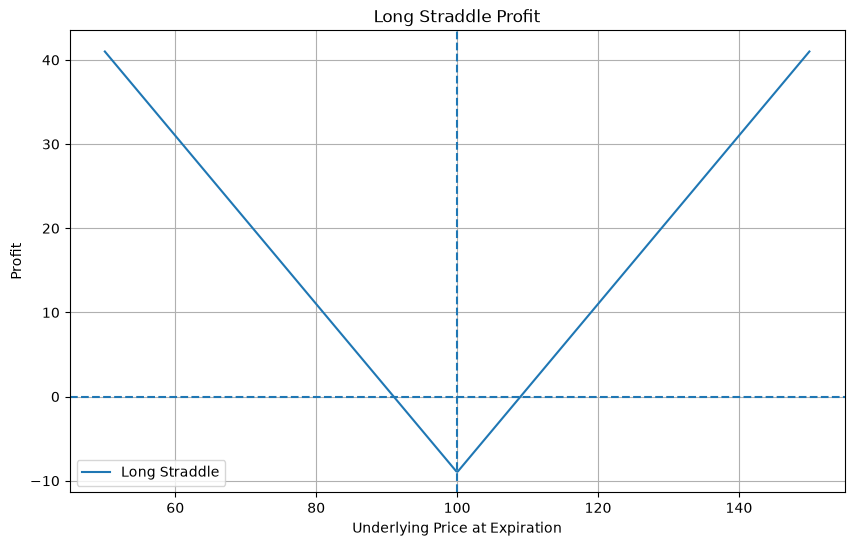

In [7]:
K = 100
call_premium = 5
put_premium = 4

straddle = long_call(S, K, call_premium) + long_put(S, K, put_premium)

plt.figure(figsize=(10, 6))
plt.plot(S, straddle, label="Long Straddle")
plt.axhline(0, linestyle="--")
plt.axvline(K, linestyle="--")
plt.title("Long Straddle Profit")
plt.xlabel("Underlying Price at Expiration")
plt.ylabel("Profit")
plt.legend()
plt.grid(True)
plt.show()

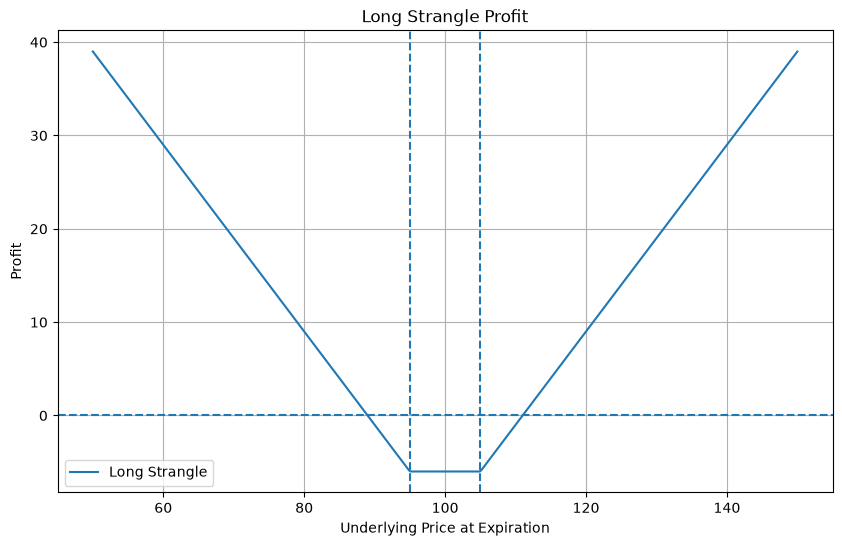

In [8]:
K_put = 95
K_call = 105
put_premium = 3
call_premium = 3

strangle = long_put(S, K_put, put_premium) + long_call(S, K_call, call_premium)

plt.figure(figsize=(10, 6))
plt.plot(S, strangle, label="Long Strangle")
plt.axhline(0, linestyle="--")
plt.axvline(K_put, linestyle="--")
plt.axvline(K_call, linestyle="--")
plt.title("Long Strangle Profit")
plt.xlabel("Underlying Price at Expiration")
plt.ylabel("Profit")
plt.legend()
plt.grid(True)
plt.show()

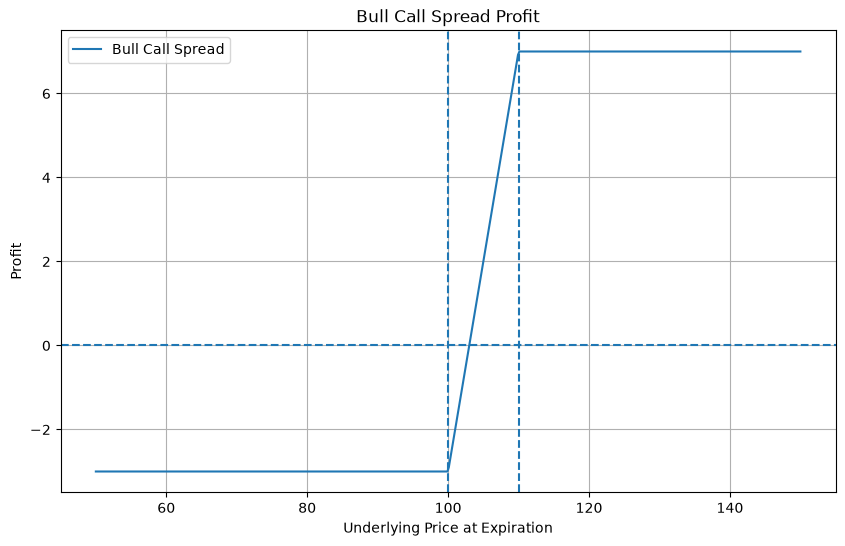

In [9]:
K1 = 100
K2 = 110
premium_long = 5
premium_short = 2

bull_call_spread = long_call(S, K1, premium_long) + short_call(S, K2, premium_short)

plt.figure(figsize=(10, 6))
plt.plot(S, bull_call_spread, label="Bull Call Spread")
plt.axhline(0, linestyle="--")
plt.axvline(K1, linestyle="--")
plt.axvline(K2, linestyle="--")
plt.title("Bull Call Spread Profit")
plt.xlabel("Underlying Price at Expiration")
plt.ylabel("Profit")
plt.legend()
plt.grid(True)
plt.show()

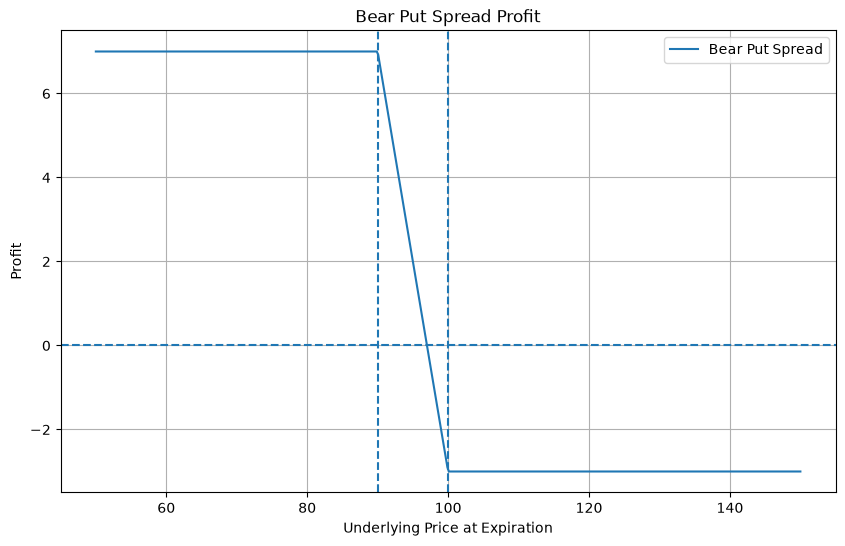

In [10]:
K_high = 100
K_low = 90
premium_long = 5
premium_short = 2

bear_put_spread = long_put(S, K_high, premium_long) + short_put(S, K_low, premium_short)

plt.figure(figsize=(10, 6))
plt.plot(S, bear_put_spread, label="Bear Put Spread")
plt.axhline(0, linestyle="--")
plt.axvline(K_low, linestyle="--")
plt.axvline(K_high, linestyle="--")
plt.title("Bear Put Spread Profit")
plt.xlabel("Underlying Price at Expiration")
plt.ylabel("Profit")
plt.legend()
plt.grid(True)
plt.show()

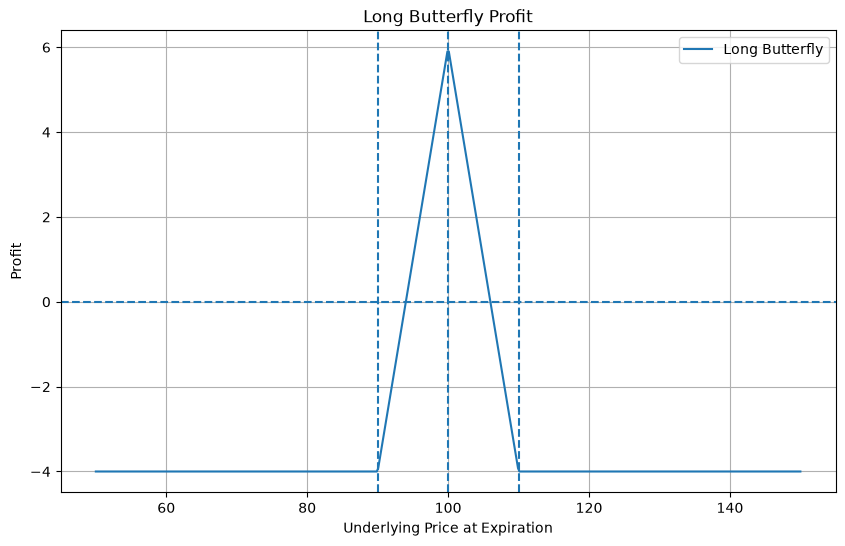

In [11]:
K1 = 90
K2 = 100
K3 = 110

premium_K1 = 12
premium_K2 = 5
premium_K3 = 2

butterfly = (
    long_call(S, K1, premium_K1)
    + 2 * short_call(S, K2, premium_K2)
    + long_call(S, K3, premium_K3)
)

plt.figure(figsize=(10, 6))
plt.plot(S, butterfly, label="Long Butterfly")
plt.axhline(0, linestyle="--")
plt.axvline(K1, linestyle="--")
plt.axvline(K2, linestyle="--")
plt.axvline(K3, linestyle="--")
plt.title("Long Butterfly Profit")
plt.xlabel("Underlying Price at Expiration")
plt.ylabel("Profit")
plt.legend()
plt.grid(True)
plt.show()

## Summary

本 notebook 绘制了五种基础期权组合策略的到期盈亏图。

我的理解：

1. Long Straddle 和 Long Strangle 都是买波动率策略，适合预期大幅波动但方向不确定的场景。
2. Bull Call Spread 是温和看涨策略，通过卖出高行权价 Call 降低成本，但限制最大收益。
3. Bear Put Spread 是温和看跌策略，通过卖出低行权价 Put 降低成本，但限制最大收益。
4. Long Butterfly 是低波动或区间策略，适合预期价格到期接近中间行权价的场景。
5. 期权组合的核心价值在于根据市场观点设计风险结构，而不是简单地判断涨跌。